Content based recommendation system - using

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


In [ ]:
df = pd.read_csv('/content/spotify_millsongdata.csv')
df.head()

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [ ]:
df.shape

(57650, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57650 entries, 0 to 57649
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   artist  57650 non-null  object
 1   song    57650 non-null  object
 2   link    57650 non-null  object
 3   text    57650 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [ ]:
df.isnull().sum()

,0
artist,0
song,0
link,0
text,0


In [ ]:
top_artists = df['artist'].value_counts().head(10)
print('top 10 artists along with their number of songs')
print(top_artists)

top 10 artists along with their number of songs
artist
Donna Summer        191
Gordon Lightfoot    189
Bob Dylan           188
George Strait       188
Loretta Lynn        187
Alabama             187
Cher                187
Reba Mcentire       187
Chaka Khan          186
Dean Martin         186
Name: count, dtype: int64


In [ ]:
df = df.drop('link',axis=1).reset_index(drop=True)

In [ ]:
# Wordcloud for lyrics
all_lyrics="".join(df['text'].dropna())
wordcloud = WordCloud(background_color='white',width=800,height=400).generate(all_lyrics)

wordcloud to visualize the most common words in the lyrics


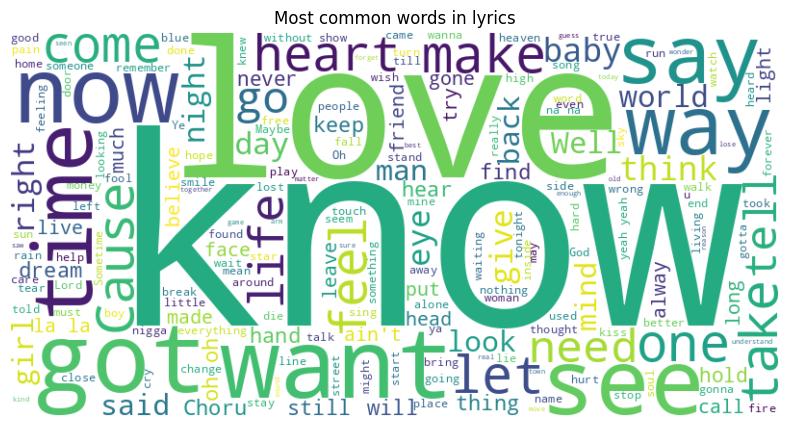

In [ ]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most common words in lyrics")
plt.show()

In [ ]:
# download nltk data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# stopwords
stop_words = set(stopwords.words('english'))

In [ ]:
# preprocessing
def preprocess_text(text):
  # remove special characters and numbers
  text = re.sub('[^a-zA-Z\s]',"",text)
  # text to lower
  text = text.lower()
  # tokens
  tokens = word_tokenize(text)
  # remove stopwords
  tokens = [word for word in tokens if word not in stop_words] # ['love','text','the']
  return " ".join(tokens) # love text the


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4051447093.py:4: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('[^a-zA-Z\s]',"",text)


In [ ]:
# Apply preprocessing to lyrics
df['cleaned_text'] = df['text'].apply(preprocess_text)

In [ ]:
df.head()

,artist,song,text,cleaned_text
0,ABBA,Ahe's My Kind Of Girl,"Look at her face, it's a wonderful face \r\nA...",look face wonderful face means something speci...
1,ABBA,"Andante, Andante","Take it easy with me, please \r\nTouch me gen...",take easy please touch gently like summer even...
2,ABBA,As Good As New,I'll never know why I had to go \r\nWhy I had...,ill never know go put lousy rotten show boy to...
3,ABBA,Bang,Making somebody happy is a question of give an...,making somebody happy question give take learn...
4,ABBA,Bang-A-Boomerang,Making somebody happy is a question of give an...,making somebody happy question give take learn...


In [ ]:
# vectorization with TF IDF
tfidfvectorizer = TfidfVectorizer(max_features=5000) # look for top 5000 important words
tfidf_matrix = tfidfvectorizer.fit_transform(df['cleaned_text'])


In [ ]:
df = df.sample(10000)

In [ ]:
# compute cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix,tfidf_matrix)
cosine_sim

In [ ]:
# recommendation function
def recommend_songs(song_name, cosine_sim=cosine_sim, df=df, top_n=5):
  # find the index of the song
  idx = df[df['song'].str.lower() == song_name.lower()].index
  if len(idx) == 0:
    return "Song not found in the dataset."
  else:
    idx = idx[0]

  # similarity scores
  sim_scores = list(enumerate(cosine_sim[idx]))
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
  sim_scores = sim_scores[1:top_n+1] # cannot recommend the current song

  # get song indices
  song_indices = [i[0] for i in sim_scores]

  # return top artists and songs
  return df[['artist', 'song']].iloc[song_indices]

In [2]:
# change the way for finding of similarity - we need to look more into this
# add lexical similarity check as well
# look into xAI and 3D visualization

In [2]:
# we need to maybe work or add more dataset
# frontend - streamlit

In [ ]:
#   Save cleaned lyrics dataframe to Parquet 
import os

output_dir = "data_parquet"
os.makedirs(output_dir, exist_ok=True)

lyrics_parquet_path = os.path.join(output_dir, "lyrics_clean.parquet")
df.to_parquet(lyrics_parquet_path, index=False)

print("Lyrics dataframe saved to:", lyrics_parquet_path)
print("Shape:", df.shape)

In [ ]:
#  2: Load Spotify audio features and align with lyrics data

audio_parquet_path = "data_parquet/spotify_audio_features.parquet"  # TODO: replace with your actual path

if os.path.exists(audio_parquet_path):
    audio_df = pd.read_parquet(audio_parquet_path)

    # Expect audio_df to contain at least: ['artist', 'song', 'tempo', 'energy', 'valence', ...]
    # If you have a stable track_id, prefer joining on that instead of text fields.
    common_cols = ["artist", "song"]

    hybrid_df = pd.merge(df, audio_df, on=common_cols, how="inner")
    print("Lyrics df:", df.shape, "Audio df:", audio_df.shape, "Merged (hybrid_df):", hybrid_df.shape)
    display(hybrid_df.head())
else:
    print(f"Audio feature file not found: {audio_parquet_path}. Please generate or place the Parquet file before running this cell.")

In [ ]:
#  3: Build hybrid features: lyrics TF-IDF + audio numerical features 
from sklearn.preprocessing import StandardScaler
from scipy import sparse

# Lyrics TF-IDF on cleaned_text
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(hybrid_df["cleaned_text"])

audio_feature_cols = ["tempo", "energy", "valence"]
audio_features = hybrid_df[audio_feature_cols].fillna(0.0).values

scaler = StandardScaler()
audio_features_scaled = scaler.fit_transform(audio_features)

audio_sparse = sparse.csr_matrix(audio_features_scaled)
hybrid_matrix = sparse.hstack([tfidf_matrix, audio_sparse])

# Precompute cosine similarity on hybrid features
hybrid_cosine_sim = cosine_similarity(hybrid_matrix, hybrid_matrix)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Audio feature shape:", audio_features_scaled.shape)
print("Hybrid matrix shape:", hybrid_matrix.shape)
print("Hybrid cosine_sim shape:", hybrid_cosine_sim.shape)

In [ ]:
#  4: Recommendation function based on hybrid similarity 
from sklearn.metrics.pairwise import cosine_similarity


def recommend_songs_hybrid(song_name, cosine_sim, df_, audio_feature_cols, top_n=5):
    """Return top-N songs most similar to the given song based on the hybrid similarity matrix."""
    # Find index of the query song (case-insensitive match)
    idx = df_[df_["song"].str.lower() == song_name.lower()].index
    if len(idx) == 0:
        return "Song not found in the merged (hybrid) dataset!"
    idx = idx[0]

   
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1 : top_n + 1]  # skip the query song itself

   
    song_indices = [i[0] for i in sim_scores]

    
    return df_[["artist", "song"] + audio_feature_cols].iloc[song_indices]


# Example usage after hybrid_df and hybrid_cosine_sim are built:
# test_song = hybrid_df["song"].iloc[0]
# recommend_songs_hybrid(test_song, cosine_sim=hybrid_cosine_sim, df_=hybrid_df, audio_feature_cols=audio_feature_cols, top_n=5)